# URBAN INFLUENCES ON THE SEABREEZE
- How do urban landscapes affect the sea breeze and/or wind capacity generation?
- Where in the Sydney region would wind generation assets best be placed?

## 0 Data Preparation
- Identify seabreeze: (method limitation) Despite the identified objects here displaying sea breeze characteristics, it is also clear that sea breezes can be difficult to separate from other frontal objects and circulations near the coast in km-scale model output.
- Method description: https://gmd.copernicus.org/articles/19/933/2026/
- Code: https://zenodo.org/records/17220916?preview_file=andrewbrown31%2Fsea_breeze-v1.1.zip
- Raw data: /g/data/gb02/mjl561/um2nc

In [1]:
import sys
import os
import numpy as np

if not hasattr(np, "in1d"):
    np.in1d = np.isin
    
import xarray as xr
import pandas as pd
from dask.distributed import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
sys.path.append('/home/561/cx5009/app/')

In [3]:
stats_output_path = "/g/data/up6/cx5009/hackathon/energy2026/Data_identified_seabreeze/"

In [4]:
client = Client()

In [5]:
from sea_breeze import (
load_model_data,
sea_breeze_funcs,
sea_breeze_filters
)

In [10]:
ds = xr.open_dataset("/g/data/gb02/mjl561/um2nc/SY_djf/SY_11p1/CTRL/wnd_ucmp-SY_SY_11p1_CTRL-v1-201611300100-201703010000.nc")
ds

/jobfs/171285559.gadi-pbs/ipykernel_2215797/3604888141.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("/g/data/gb02/mjl561/um2nc/SY_djf/SY_11p1/CTRL/wnd_ucmp-SY_SY_11p1_CTRL-v1-201611300100-201703010000.nc")


<xarray.Dataset> Size: 9GB
Dimensions:                  (time: 2184, model_level_number: 8, latitude: 320,
                              longitude: 400)
Coordinates:
  * time                     (time) datetime64[ns] 17kB 2016-11-30T01:00:00 ....
    forecast_period          (time) timedelta64[ns] 17kB ...
  * model_level_number       (model_level_number) int64 64B 1 2 3 4 5 6 7 8
    level_height             (model_level_number) float64 64B ...
    sigma                    (model_level_number) float64 64B ...
  * latitude                 (latitude) float64 3kB -51.48 -51.37 ... -16.39
  * longitude                (longitude) float64 3kB 129.1 129.2 ... 172.9 173.0
    forecast_reference_time  datetime64[ns] 8B ...
Data variables:
    wnd_ucmp                 (time, model_level_number, latitude, longitude) float32 9GB ...
Attributes: (12/40)
    source:                         Data from Met Office Unified Model
    um_version:                     13.5
    geospatial_lat_min:             -51.48
    geospatial_lat_max:             -16.39
    geospatial_lat_resolution:      0.11
    geospatial_lat_resolution_min:  0.109996796
    ...                             ...
    fletcher32:                     True
    chunksizes:                     [24  3 53 68]
    NCO:                            netCDF Operators version 5.3.3 (Homepage ...
    stash_vocabulary:               http://reference.metoffice.gov.uk/um/stash
    stash_references:               /g/data/access/projects/access/umdir/vn13...
    cf_standard_name_table:         cf-standard-name-table.xml.v78

In [27]:
print(ds.time.values[:5])

['2016-11-30T01:00:00.000000000' '2016-11-30T02:00:00.000000000'
 '2016-11-30T03:00:00.000000000' '2016-11-30T04:00:00.000000000'
 '2016-11-30T05:00:00.000000000']


In [19]:
print(float(ds.latitude[1]-ds.latitude[0]))
print(float(ds.longitude[1]-ds.longitude[0]))

0.1100006103515625
0.1100006103515625


In [22]:
print(ds.level_height.values)
print(ds.model_level_number.values)


[ 10.     36.664  76.664 130.    196.664 276.664 370.    476.664]
[1 2 3 4 5 6 7 8]


### 0.1 Coastline Angel Calculation

In [6]:
#Lat lon and height bounds (Perth, Australia). Height bounds chosen approximately as the typical maximum extent of the PBL
lat_slice = slice(-35.5,-32.269001)
lon_slice = slice(149.1505,153.1915)


In [9]:
def load_static(exp_season,exp_res,exp_id,lon_slice,lat_slice,chunks="auto"):

    """
    Load static fields for the ACCESS-rAM3 Sydney experiment, stored on the gb02 project.

    Parameters
    ----------
    exp_season : str
        Experiment Season. Must be one of 'SY_djf' or 'SY_jja'.
    exp_res : str
        Experiment Resolution. Must be one of 'SY_1', 'SY_5' or 'SY_11p1'.
    exp_id : str
        Experiment ID. Must be one of 'CTRL' or 'NO-URBAN'.
    lon_slice : slice or array-like
        Slice or indices to restrict longitude domain.
    lat_slice : slice or array-like
        Slice or indices to restrict latitude domain.
    chunks : str or dict, optional
        Chunking for xarray open_mfdataset (default is "auto").

    Returns
    -------
    orog : xarray.DataArray
        Orography field for the selected domain.
    lsm : xarray.DataArray
        Binary land-sea mask (1 for land, 0 for sea) for the selected domain.
    """

    orog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks).sel(latitude=lat_slice,longitude=lon_slice)
    orog = orog.rename({
        "latitude": "lat",
        "longitude": "lon"
    })
    
    lsm = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/lnd_mask-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks).sel(latitude=lat_slice,longitude=lon_slice)
    lsm = lsm.rename({
        "latitude": "lat",
        "longitude": "lon"
    })
    land_mask = xr.where(lsm.lnd_mask != 0, 1, 0)
    
    return orog.topog, land_mask


In [10]:
#Load land sea mask
orog, lsm = load_static('SY_djf','SY_11p1','CTRL',lon_slice,lat_slice)

#Compute coastline angles
angle_ds = load_model_data.get_coastline_angle_kernel(
    lsm,
    R=4,
    latlon_chunk_size=8,
    compute=True,
    smooth=False)

/jobfs/171403774.gadi-pbs/ipykernel_1050594/299786971.py:29: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  orog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc",chunks=chunks).sel(latitude=lat_slice,longitude=lon_slice)
/jobfs/171403774.gadi-pbs/ipykernel_1050594/299786971.py:35: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the pre

INFO: Take the weighted mean and convert complex numbers to an angle and magnitude...
INFO: Calculating the sum of the weights...
INFO: Calculating variance...
INFO: Calculating minimum distance to the coast...


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in power
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.05/lib/python3.12/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


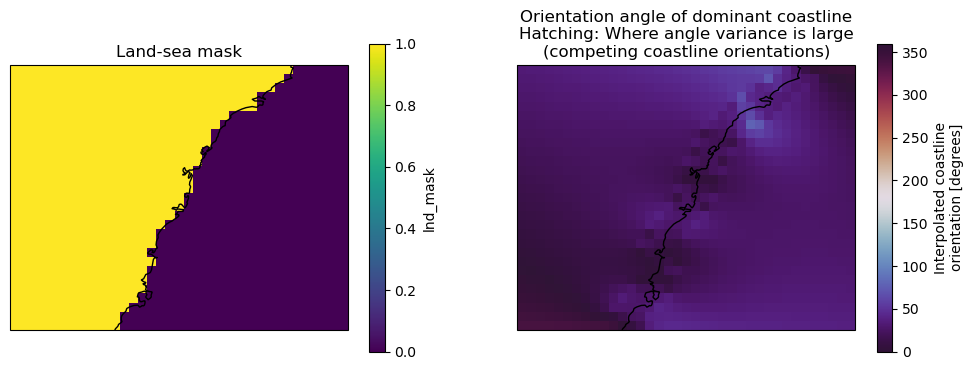

In [11]:
#Plot the model land sea mask and coastline angles
plt.figure(figsize=[12,4])
ax = plt.subplot(1,2,1,projection=ccrs.PlateCarree())
lsm.plot()
ax.coastlines()
plt.title("Land-sea mask")
ax = plt.subplot(1,2,2,projection=ccrs.PlateCarree())
angle_ds.angle_interp.plot(cmap="twilight_shifted",vmin=0,vmax=360)
xr.plot.contourf(angle_ds.variance_interp,levels=[0.,0.5],hatches=["","/////"],colors="none",add_colorbar=False)
ax.coastlines()
plt.title("Orientation angle of dominant coastline\nHatching: Where angle variance is large\n(competing coastline orientations)");


### 0.2 Seabreeze Diagnostics

In [12]:
#Time bounds for a single case (using 8 hours of data)
t1 = "2016-11-30 01:00"
t2 = "2016-12-01 00:00"
      
#Lat lon and height bounds (Perth, Australia). Height bounds chosen approximately as the typical maximum extent of the PBL
lat_slice = slice(-35.5,-32.269001)
lon_slice = slice(149.1505,153.1915)
hgt_slice = slice(0,4500)

In [19]:
def interp_model_level_to_z(z_da,var_da,mdl_dim,heights):

    """
    Linearly interpolate from model level data to height levels. Supported for ACCESS-rAM3 data.

    Parameters
    ----------
    z_da : xarray.DataArray
        Height data (either AGL or above geoid) for each model level.
    var_da : xarray.DataArray
        Variable to interpolate, with the same model level dimension as z_da.
    mdl_dim : str
        Name of the model level dimension (e.g., 'lev', 'hybrid'). Model levels must be decreasing (height increasing).
    heights : numpy.ndarray
        Array of target height levels to interpolate to.

    Returns
    -------
    xarray.DataArray
        Variable interpolated to the specified height levels. If the requested height is below the lowest model level, data from the lowest model level is returned. If above the highest model level, NaNs are returned.

    Notes
    -----
    - If the requested height is below the lowest model level, data from the lowest model level is returned.
    - Note that for ERA5, the lowest model level is within the first few 10s of meters above the surface.
    - If the requested height is above the highest model level, then NaNs are returned.
    """

    interp_da = xr.apply_ufunc(interp_scipy,
                heights,
                z_da,
                var_da,
                input_core_dims=[ ["height"], [mdl_dim], [mdl_dim]],
                output_core_dims=[["height"]],
                exclude_dims=set((mdl_dim,)),
                dask="parallelized",
                output_dtypes=var_da.dtype,
                vectorize=True)
    interp_da["height"] = heights
    
    return interp_da

def load_variable(vname, t1, t2, exp_season, exp_res, exp_id, lon_slice, 
                  lat_slice, freq, hgt_slice=None, chunks="auto", staggered=None, 
                  dx=0.022, smooth=False, smooth_axes=None, sigma=2, interp_hgts=False, dh=100):

    """
    Load variables from the ACCESS-rAM3 Sydney experiment, stored on the gb02 project.

    Parameters
    ----------
    vname : str
        Name of ACCESS-rAM3 Sydney variable to load.
    t1 : str
        Start time in "%Y-%m-%d %H:%M".
    t2 : str
        End time in "%Y-%m-%d %H:%M".
    exp_season : str
        Experiment Season. Must be one of 'SY_djf' or 'SY_jja'.
    exp_res : str
        Experiment Resolution. Must be one of 'SY_1', 'SY_5' or 'SY_11p1'.
    exp_id : str
        Experiment ID. Must be one of 'CTRL' or 'NO-URBAN'.
    lon_slice : slice or array-like
        Slice or indices to restrict longitude domain.
    lat_slice : slice or array-like
        Slice or indices to restrict latitude domain.
    freq : str
        Time frequency. Must be "10min", "1hr", or "1hrPlev".
    hgt_slice : slice or array-like, optional
        Slice to restrict data in the vertical (in m).
    chunks : str or dict, optional
        Chunking for xarray open_mfdataset (default is "auto").
    staggered : str, optional
        If not None, the data is staggered in the specified dimension ("lat", "lon", or "time").
    dx : float, optional
        The distance to stagger the data by if staggered in lat or lon (in degrees, default is 0.022 for AUS2200).
    smooth : bool, optional
        If True, smooth the data using a Gaussian filter.
    smooth_axes : iterable, optional
        If smoothing, the axes to smooth over.
    sigma : float, optional
        If smoothing, the sigma of the Gaussian filter (default is 2).
    interp_hgts : bool, optional
        If True, interpolate the data to regular height levels.
    dh : int, optional
        If interpolating to height levels, the height increment (in m, default is 100).

    Returns
    -------
    da : xarray.DataArray
        The requested variable, optionally smoothed and/or interpolated to regular height levels.

    Notes
    -----
    - This code currently does not support interpolating in height, as the relevant AUS2200 variable (Z_agl) is not on bs94. A version of Z_agl has been pre-computed and stored on ng72, and this is used if interp_hgts is True, but may not be accessible to all users.
    - If the data is being smoothed or interpolated, the relevant dimensions are set to -1 in the chunks dict.
    - De-staggering in lat/lon can fail at the domain edges depending on the slice used. If this happens, try extending the slice by one grid point in the relevant direction.
    """

    #Set up the time and lat/lon slices if the data is staggered
    orog, lsm = load_static(exp_season,exp_res,exp_id,lon_slice,lat_slice) # Chang Changed
    if staggered is not None:
        if staggered == "lat":
            lat_slice=slice(lat_slice.start-(dx*0.5),lat_slice.stop+(dx*0.5))
        elif staggered == "lon":
            lon_slice=slice(lon_slice.start-(dx*0.5),lon_slice.stop+(dx*0.5))
        elif staggered == "time":
            if freq == "10min":
                time_delta = dt.timedelta(minutes=10)
                freq_str = freq
            elif (freq == "1hr") | (freq == "1hrPlev"):
                time_delta = dt.timedelta(hours=1)
                freq_str = "1h"
            unstaggered_times = pd.date_range(t1,t2,freq=freq_str)
            t1 = pd.to_datetime(t1) - time_delta
            t2 = pd.to_datetime(t2) + time_delta
        else:
            raise ValueError("Invalid stagger dim")
    
    #Load the data from disk. If hgt_slice is not None, then we are loading 3D data
    fnames = f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/{vname}-SY_{exp_res}_{exp_id}-v1-201611300100-201703010000.nc"
    if hgt_slice is None:
        da = xr.open_dataset(
            fnames,
            chunks=chunks
        ).sel(
            latitude=lat_slice,
            longitude=lon_slice
        ).sel(
            time=slice(t1,t2)
        )[vname]
        
        da = da.rename({
            "latitude": "lat",
            "longitude": "lon"
        })
    else:
        da = xr.open_dataset(
            fnames,
            chunks=chunks
        ).sel(
            latitude=lat_slice,
            longitude=lon_slice,
            model_level_number=hgt_slice
        ).sel(
            time=slice(t1,t2)
        )[vname]
        
        da = da.rename({
            "latitude": "lat",
            "longitude": "lon",
            "model_level_number": "lev"
        })
    
    #Destagger the data if required
    # if staggered == "lat":
    #     da = (da.isel(lat=slice(0,-1)).assign_coords({"lat":lsm["lat"].values}) +
    #                     da.isel(lat=slice(1,da.lat.shape[0])).assign_coords({"lat":lsm["lat"].values})) / 2        
    # if staggered == "lon":
    #     da = (da.isel(lon=slice(0,-1)).assign_coords({"lon":lsm["lon"].values}) +
    #                    da.isel(lon=slice(1,da.lon.shape[0])).assign_coords({"lon":lsm["lon"].values})) / 2

    # Chang change
    if staggered == "lat":
        new_lat = 0.5 * (da.lat.values[:-1] + da.lat.values[1:])
    
        da = (
            da.isel(lat=slice(0, -1)).assign_coords(lat=new_lat)
            +
            da.isel(lat=slice(1, None)).assign_coords(lat=new_lat)
        ) / 2
    
    if staggered == "lon":
        new_lon = 0.5 * (da.lon.values[:-1] + da.lon.values[1:])
    
        da = (
            da.isel(lon=slice(0, -1)).assign_coords(lon=new_lon)
            +
            da.isel(lon=slice(1, None)).assign_coords(lon=new_lon)
        ) / 2
    if staggered == "time":
        da = (da.isel(time=slice(0,-1)).assign_coords({"time":unstaggered_times}) +\
                    da.isel(time=slice(1,da.time.shape[0])).assign_coords({"time":unstaggered_times})) / 2
        
    #Optional smoothing using gaussian filter
    if smooth:
        if smooth_axes is not None:
            for ax in smooth_axes:
                chunks[ax] = -1
            smooth_axes = (np.where(np.in1d(da.isel(time=0).dims,smooth_axes))[0])
        else:
            chunks["lev"] = -1
            chunks["lat"] = -1
            chunks["lon"] = -1
        
        da = da.drop_vars(
            ["level_height", "sigma"],
            errors="ignore"
        )
        
        da = da.map_blocks(
            load_model_data.gaussian_filter_time_slice,
            kwargs={"sigma":sigma,"axes":smooth_axes},
            template=da
        )

    #Interpolate to regular height levels
    if interp_hgts:
        chunks["lev"] = -1
        #da = da.chunk({"lev":-1}).interp(lev=np.arange(hgt_slice.start,hgt_slice.stop+dh,dh),method="linear",kwargs={"fill_value":"extrapolate"})
        #Created in aus2200_hybrid_height_calc()
        ds_geop = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/geop_ht_rho-SY_{exp_res}_{exp_id}-v1-201611300100-201703010000.nc")
        ds_geop = ds_geop.rename({
            "latitude": "lat",
            "longitude": "lon",
            "model_level_number": "lev"
        })
        
        ds_topog = xr.open_dataset(f"/g/data/gb02/mjl561/um2nc/{exp_season}/{exp_res}/{exp_id}/topog-SY_{exp_res}_{exp_id}-v1.nc")
        ds_topog = ds_topog.rename({
            "latitude": "lat",
            "longitude": "lon"
        })
        
        Z_agl = ds_geop.geop_ht_rho - ds_topog.topog
        
        # Z_agl = xr.open_zarr("/g/data/ng72/ab4502/sea_breeze_detection/aus2200_z_agl.zarr/",
        #                      chunks=chunks).Z_agl.sel(lev=da.lev,lat=da.lat,lon=da.lon)
        da = interp_model_level_to_z(
            Z_agl,
            da.chunk({"lev":-1}),
            "lev",
            np.arange(hgt_slice.start,hgt_slice.stop+dh,dh)
            )        

    da = da.assign_attrs({"smoothed":smooth})
    if smooth:
        da = da.assign_attrs({"gaussian_smoothing_sigma":sigma})

    # Chang add
    target_lat = lsm.lat.values
    target_lon = lsm.lon.values
    
    da = da.interp(
        lat=target_lat,
        lon=target_lon,
        method="linear"
    )
    
    return da


In [20]:
#Set chunks for loading data
#Note because of our strategy applying xr.DataArray.map_blocks for smoothing, we need to 
# have time chunks of size 1.
chunks = {"lev":{},"time":1,"lat":-1,"lon":-1}

#Set smoothing option to True (gaussian smoothing filter with a sigma of 4. See scipy.ndimage.gaussian_filter)
smooth = True
sigma = 4

#Load V wind
va = load_variable(
    "wnd_vcmp",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    staggered="lat",
    dx=0.11,
    smooth=smooth,
    sigma=sigma,
    hgt_slice=hgt_slice,
    interp_hgts=False)

#Load U wind
ua = load_variable(
    "wnd_ucmp",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    staggered="lon",
    dx=0.11, # for 11p1
    smooth=smooth,
    sigma=sigma,
    hgt_slice=hgt_slice,
    interp_hgts=False)

#Load boundary layer depth
zmla = load_variable(
    "abl_ht",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    smooth=smooth,
    sigma=sigma)

#For frontogenesis
#Note that when we load in these surface variables, we will trigger the computations with persist(), to avoid
# chunking conflicts later when we compute some time rates of change

#Load surface V wind
vas = load_variable(
    "vwnd10m_b",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    staggered="lat",
    smooth=smooth,
    sigma=sigma)

#Load surface U wind
uas = load_variable(
    "uwnd10m_b",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    staggered="lon",
    smooth=smooth,
    sigma=sigma)

#Load surface specific humidity
hus = load_variable(
    "qsair_scrn",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    smooth=smooth,
    sigma=sigma)

# #Restrict everything to hourly (consistent with ua and va)
# vas = vas.sel(time=vas.time.dt.minute==0)
# uas = uas.sel(time=uas.time.dt.minute==0)

#For fuzzy logic algorithm
#Load surface air temperature
tas = load_variable(
    "temp_scrn",
    t1,
    t2,
    'SY_djf',
    'SY_11p1',
    'CTRL',
    lon_slice,
    lat_slice,
    "1hr",
    chunks=chunks,
    smooth=smooth,
    sigma=sigma)


In [21]:
#Sea breeze index
wind = xr.Dataset({"u":ua,"v":va})
sbi = sea_breeze_funcs.calc_sbi(wind,
                            angle_ds.angle_interp,
                            subtract_mean=False,
                            height_method="blh",
                            blh_da=zmla,
                            vert_coord="lev")


In [22]:
#Moisture frontogenesis
F = sea_breeze_funcs.kinematic_frontogenesis(
        hus,
        uas,
        vas
    ) 


In [23]:
#Fuzzy logic algorithm

#Compute the hourly rate of change in temperature, wind, and moisture. 
hourly_change = sea_breeze_funcs.hourly_change(
    hus,
    tas,
    uas,
    vas,
    angle_ds.angle_interp
)

#Combine into "fuzzy function"
F_fuzzy = field = sea_breeze_funcs.fuzzy_function_combine(
    hourly_change.wind_change,
    hourly_change.q_change,
    hourly_change.t_change, combine_method="mean")


### 0.3 Object detection and filtering

## 1 The character of sea breezes near Sydney
- Dural Cycle of the wind speed, direction, timing, and vertical structure at turbine height

### 1.1 Seasonality & Resolusion (topography/ surface roughness)

## 2 Calculate capacity factors during sea breeze events

## 3 Synthesise and visualise the urban effect